بسم الله الرحمن الرحيم
الحمد لله الصلوة والسلام على اشرف المخلوقين وعلى آله وصحبه اجمعين امّا بعد
اشهد ان لا اله الّا الله واشهد انّ محمّد رسول الله

In [17]:
# ============================================================
# 1. IMPORT REQUIRED PACKAGES
# ============================================================

!pip -q install openpyxl pingouin scikit-posthocs

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    ttest_ind,
    f_oneway,
    pearsonr,
    levene
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

import pingouin as pg
import scikit_posthocs as sp

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

In [18]:
# ============================================================
# 2. LOAD EXCEL DATA
# ============================================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset shape:", df.shape)

print("\nNumber of respondents:", len(df))

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(i, ":", repr(col))

Saving sadiq dataset.csv to sadiq dataset (2).csv
Dataset shape: (150, 44)

Number of respondents: 150

Column names:
1 : 'Timestamp'
2 : ' Do you use any digital services(e.g., online banking, e-commerce)?'
3 : 'Gender'
4 : 'Age'
5 : 'Educational Qualification'
6 : 'Occupation'
7 : 'Monthly Income'
8 : 'Residence'
9 : 'How frequently do you use digital services?'
10 : 'How many years have you been using digital services?'
11 : 'Which of the following is the strongest password?'
12 : 'You receive an email asking you to click a link and urgently confirm your bank account details. What is the safest action?'
13 : 'Which of the following is a common indicator of a phishing message?'
14 : 'What is the primary purpose of two-factor authentication (2FA)?'
15 : 'Which website address generally indicates that the connection is encrypted?'
16 : 'What is the most appropriate action when a legitimate security update is available for your device or application?'
17 : 'If a message requests your ba

In [19]:
# ============================================================
# 3. CREATE CLEAN COLUMN NAMES
# ============================================================

original_columns = df.columns.tolist()

clean_columns = [
    f"var_{i+1}"
    for i in range(len(df.columns))
]

column_mapping = pd.DataFrame({
    "Original Column": original_columns,
    "Clean Column": clean_columns
})

df.columns = clean_columns

display(column_mapping)

,Original Column,Clean Column
0,Timestamp,var_1
1,"Do you use any digital services(e.g., online ...",var_2
2,Gender,var_3
3,Age,var_4
4,Educational Qualification,var_5
5,Occupation,var_6
6,Monthly Income,var_7
7,Residence,var_8
8,How frequently do you use digital services?,var_9
9,How many years have you been using digital ser...,var_10


In [20]:
# ============================================================
# 4. ASSIGN MEANINGFUL VARIABLE NAMES
# ============================================================

new_names = {

    # Screening
    "var_1": "timestamp",
    "var_2": "digital_service_user",

    # Demographics
    "var_3": "gender",
    "var_4": "age",
    "var_5": "education",
    "var_6": "occupation",
    "var_7": "income",
    "var_8": "residence",
    "var_9": "usage_frequency",
    "var_10": "years_using",

    # Cybersecurity Awareness
    "var_11": "C1",
    "var_12": "C2",
    "var_13": "C3",
    "var_14": "C4",
    "var_15": "C5",
    "var_16": "C6",
    "var_17": "C7",
    "var_18": "C8",
    "var_19": "C9",
    "var_20": "C10",

    # Perceived Data Privacy
    "var_21": "D1",
    "var_22": "D2",
    "var_23": "D3",
    "var_24": "D4",
    "var_25": "D5",
    "var_26": "D6",
    "var_27": "D7",

    # System Reliability
    "var_28": "E1",
    "var_29": "E2",
    "var_30": "E3",
    "var_31": "E4",
    "var_32": "E5",
    "var_33": "E6",
    "var_34": "E7",

    # Consumer Trust
    "var_35": "F1",
    "var_36": "F2",
    "var_37": "F3",
    "var_38": "F4",
    "var_39": "F5",
    "var_40": "F6",
    "var_41": "F7",
    "var_42": "F8",
    "var_43": "F9",
    "var_44": "F10"
}

df = df.rename(columns=new_names)

print("New columns:")
print(df.columns.tolist())

New columns:
['timestamp', 'digital_service_user', 'gender', 'age', 'education', 'occupation', 'income', 'residence', 'usage_frequency', 'years_using', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10']


In [21]:
# ============================================================
# 5. DATA VERIFICATION
# ============================================================

print("Dataset dimensions:", df.shape)

display(df.head())

print("\nMissing values:")
missing = df.isnull().sum()

display(
    missing[missing > 0]
    .sort_values(ascending=False)
)

Dataset dimensions: (150, 44)


,timestamp,digital_service_user,gender,age,education,occupation,income,residence,usage_frequency,years_using,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,D1,D2,D3,D4,D5,D6,D7,E1,E2,E3,E4,E5,E6,E7,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
0,2026/08/19 9:44:15 PM GMT+1,Yes,Male,21–30,Postgraduate,Student,£1001 - £1500,Urban,Daily,More than 6 years,T7#mQ9!vL2@p,Avoid the link and contact the bank through it...,An urgent request for personal or financial in...,To provide an additional layer of identity ver...,https://example.com,Ignore it permanently,Do not provide the information and verify thro...,Avoid sensitive transactions on the unsecured ...,Change the password and follow the provider's ...,They can help fix security vulnerabilities,Neutral,Strongly agree,Strongly agree,Neutral,Strongly agree,Neutral,Strongly disagree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree
1,2026/08/19 9:52:43 PM GMT+1,Yes,Female,21–30,Undergraduate,Student,Below £1000,Urban,Daily,More than 6 years,T7#mQ9!vL2@p,Avoid the link and contact the bank through it...,An urgent request for personal or financial in...,To prevent all types of cyberattacks,https://example.com,Install the security update when appropriate,Do not provide the information and verify thro...,Avoid sensitive transactions on the unsecured ...,Change the password and follow the provider's ...,They can help fix security vulnerabilities,Strongly agree,Strongly agree,Strongly disagree,Strongly Disagree,Strongly agree,Strongly disagree,Neutral,Strongly Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Neutral,Neutral,Agree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Neutral,Strongly Agree,Strongly Agree
2,2026/08/19 10:05:46 PM GMT+1,Yes,Male,21–30,Postgraduate,Student,£1001 - £1500,Semi-Urban,Weekly,4–6 years,T7#mQ9!vL2@p,Avoid the link and contact the bank through it...,An urgent request for personal or financial in...,To provide an additional layer of identity ver...,An unfamiliar shortened URL,Install the security update when appropriate,Do not provide the information and verify thro...,Avoid sensitive transactions on the unsecured ...,Change the password and follow the provider's ...,They can help fix security vulnerabilities,Agree,Agree,Agree,Neutral,Neutral,Neutral,Disagree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree,Agree
3,2026/08/19 10:07:48 PM GMT+1,Yes,Male,21–30,Undergraduate,Student,£1001 - £1500,Semi-Urban,Weekly,1–3 years,T7#mQ9!vL2@p,Avoid the link and contact the bank through it...,An urgent request for personal or financial in...,To provide an additional layer of identity ver...,http://example.com,Install the security update when appropriate,Do not provide the information and verify thro...,Avoid sensitive transactions on the unsecured ...,Change the password and follow the provider's ...,They can help fix security vulnerabilities,Strongly agree,Strongly agree,Agree,Agree,Strongly agree,Agree,Neutral,Strongly Agree,Agree,Strongly Agree,Neutral,Agree,Neutral,Agree,Agree,Agree,Strongly Agree,Neutral,Agree,Neutral,Neutral,Agree,Agree,Agree
4,2026/08/19 11:20:18 PM GMT+1,Yes,Male,21–30,Postgraduate,Student,£1001 - £1500,Urban,Daily,1–3 years,T7#mQ9!vL2@p,Avoid the link and contact the bank through it...,A routine service notification,To automatically change passwords,An unfamiliar shortened URL,Disable security notifications,Do not provide the information and verify thro...,Avoid sensitive transactions on the unsecured ...,Ignore the incident,They can help fix security vulnerabilities,Strongly agree,Strongly agree,Neutral,Neutral,Neutral,Neutral,Strongly disagree,Neutral,Neutral,Agree,Agree,Agree,Neutral,Agree,Neutral,Agree,Agree,Disagree,Agree,Strongly Agree,Strongly Agree,Strongly Agree,Agree,Agree



Missing values:


,0
gender,26
age,26
education,26
occupation,26
income,26
residence,26
usage_frequency,26
years_using,26
C1,26
C2,26


In [22]:
# ============================================================
# 6. SCREENING
# ============================================================

print(
    df["digital_service_user"]
    .value_counts(dropna=False)
)

digital_service_user
Yes    124
No      26
Name: count, dtype: int64


In [23]:
# ============================================================
# STANDARDISE SCREENING VARIABLE
# ============================================================

df["digital_service_user_clean"] = (
    df["digital_service_user"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(
    df["digital_service_user_clean"]
    .value_counts(dropna=False)
)

digital_service_user_clean
yes    124
no      26
Name: count, dtype: int64


In [24]:
# ============================================================
# KEEP VALID DIGITAL SERVICE USERS
# ============================================================

yes_values = [
    "yes",
    "y",
    "1",
    "true"
]

df = df[
    df["digital_service_user_clean"]
    .isin(yes_values)
].copy()

df.reset_index(drop=True, inplace=True)

print(
    "Valid respondents after screening:",
    len(df)
)

Valid respondents after screening: 124


In [25]:
# ============================================================
# 7. VARIABLE GROUPS
# ============================================================

demographic_vars = [
    "gender",
    "age",
    "education",
    "occupation",
    "income",
    "residence",
    "usage_frequency",
    "years_using"
]

awareness_items = [
    "C1", "C2", "C3", "C4", "C5",
    "C6", "C7", "C8", "C9", "C10"
]

privacy_items = [
    "D1", "D2", "D3", "D4",
    "D5", "D6", "D7"
]

reliability_items = [
    "E1", "E2", "E3", "E4",
    "E5", "E6", "E7"
]

trust_items = [
    "F1", "F2", "F3", "F4", "F5",
    "F6", "F7", "F8", "F9", "F10"
]

In [26]:
# ============================================================
# CHECK VARIABLES
# ============================================================

required_variables = (
    demographic_vars +
    awareness_items +
    privacy_items +
    reliability_items +
    trust_items
)

missing_variables = [
    x for x in required_variables
    if x not in df.columns
]

if len(missing_variables) == 0:
    print("All required variables are available.")
else:
    print("Missing variables:")
    print(missing_variables)

All required variables are available.


OBJECTIVE 1
Demographic Profile and Levels of the Main Constructs
8. Demographic Frequency and Percentage

In [27]:
# ============================================================
# 8. DEMOGRAPHIC PROFILE
# ============================================================

def frequency_percentage(data, variable):

    frequency = data[variable].value_counts(
        dropna=False
    )

    percentage = (
        data[variable]
        .value_counts(
            normalize=True,
            dropna=False
        ) * 100
    )

    result = pd.DataFrame({
        "Frequency": frequency,
        "Percentage": percentage.round(2)
    })

    return result


for variable in demographic_vars:

    print("\n" + "=" * 70)
    print(variable.upper())
    print("=" * 70)

    display(
        frequency_percentage(
            df,
            variable
        )
    )


GENDER


,Frequency,Percentage
gender,,
Male,83,66.9400
Female,40,32.2600
Prefer not to say,1,0.8100



AGE


,Frequency,Percentage
age,,
21–30,98,79.0300
Below 20,18,14.5200
31-40,7,5.6500
41-50,1,0.8100



EDUCATION


...

,Frequency,Percentage
residence,,
Urban,47,37.9000
Semi-Urban,41,33.0600
Rural,36,29.0300



USAGE_FREQUENCY


,Frequency,Percentage
usage_frequency,,
Daily,80,64.5200
Weekly,24,19.3500
Occasionally,12,9.6800
Monthly,8,6.4500



YEARS_USING


,Frequency,Percentage
years_using,,
1–3 years,46,37.1000
4–6 years,30,24.1900
More than 6 years,29,23.3900
Less than 1 year,19,15.3200


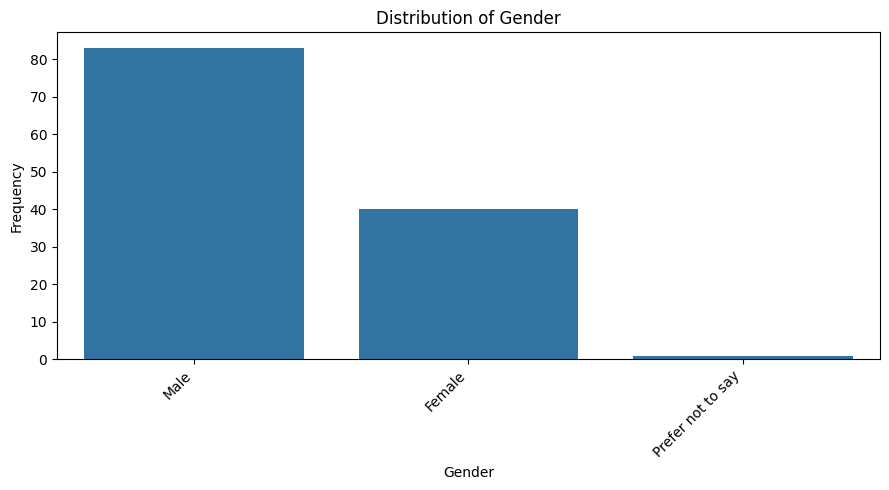

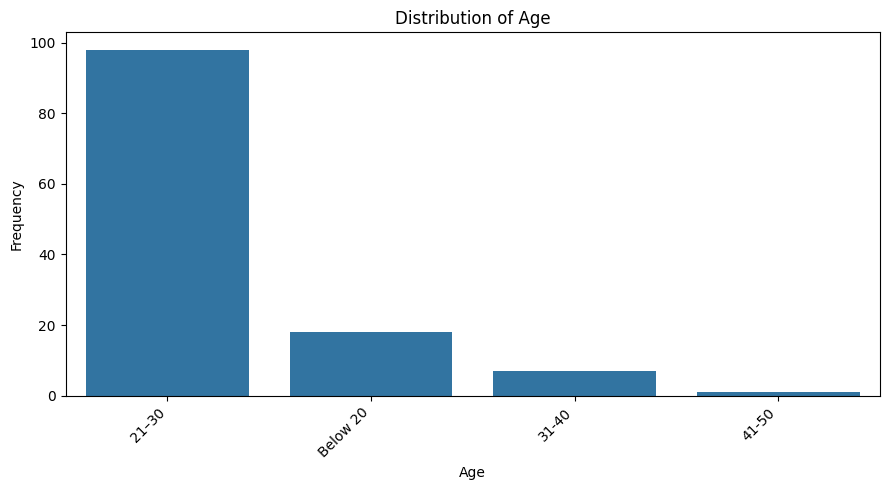

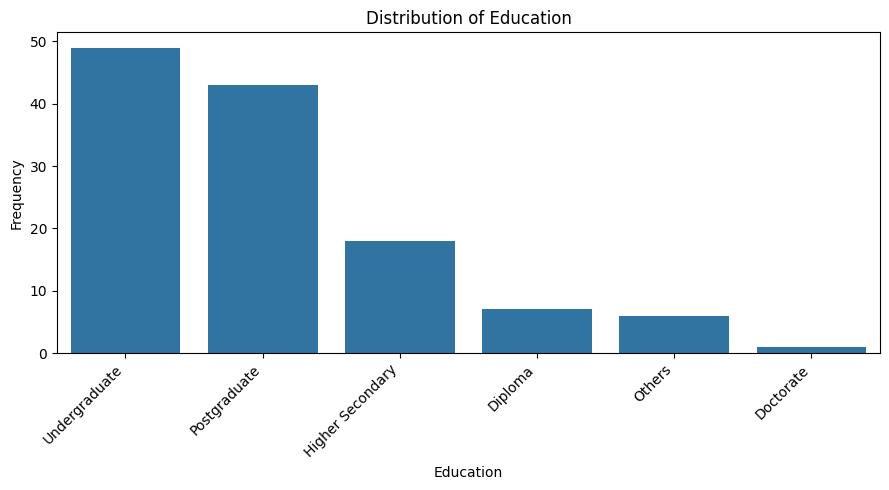

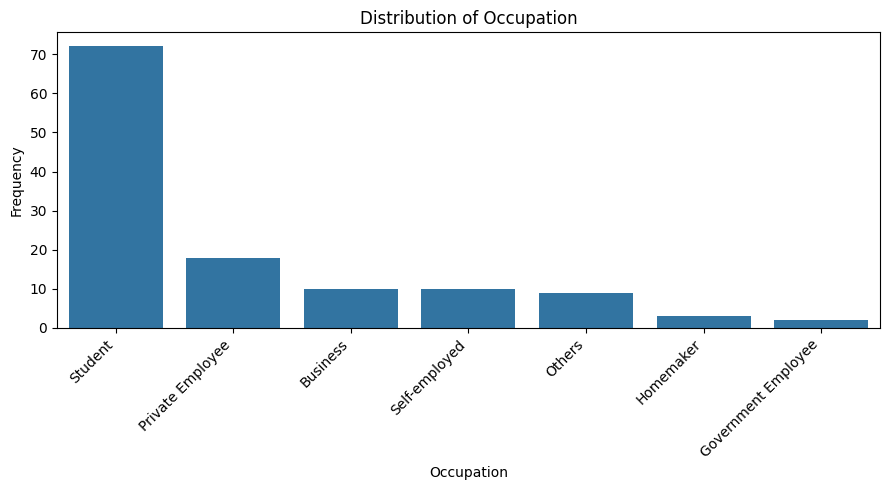

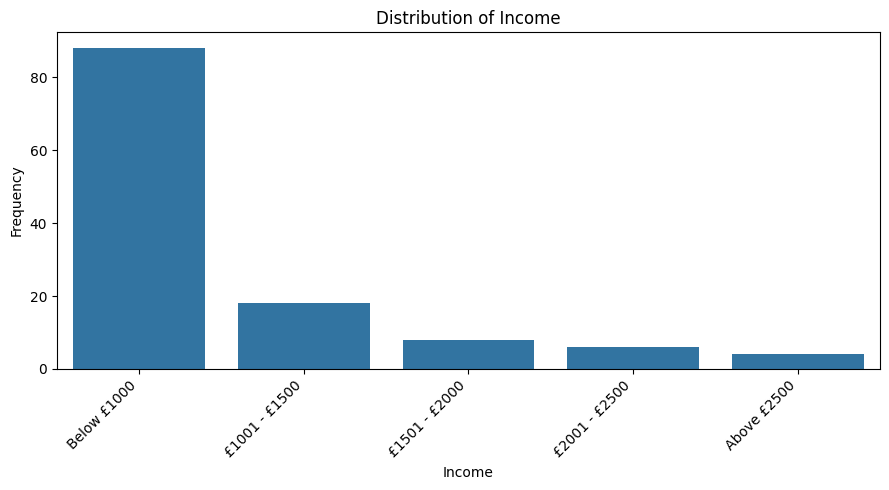

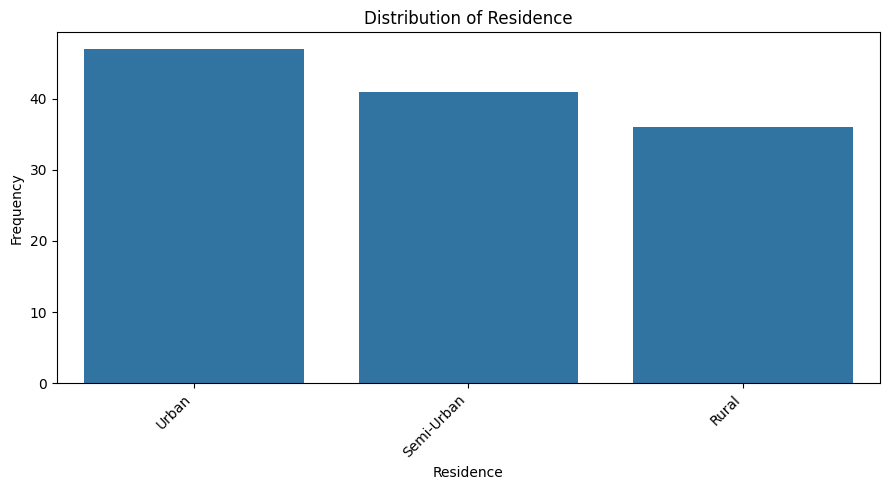

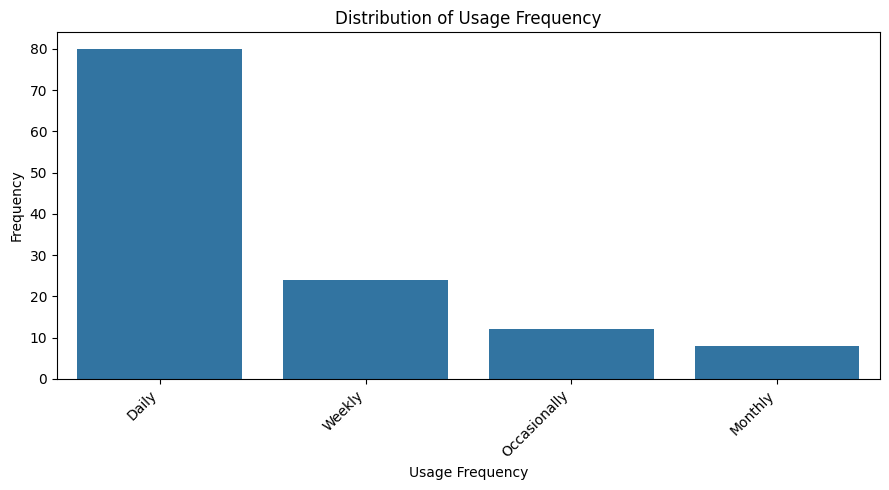

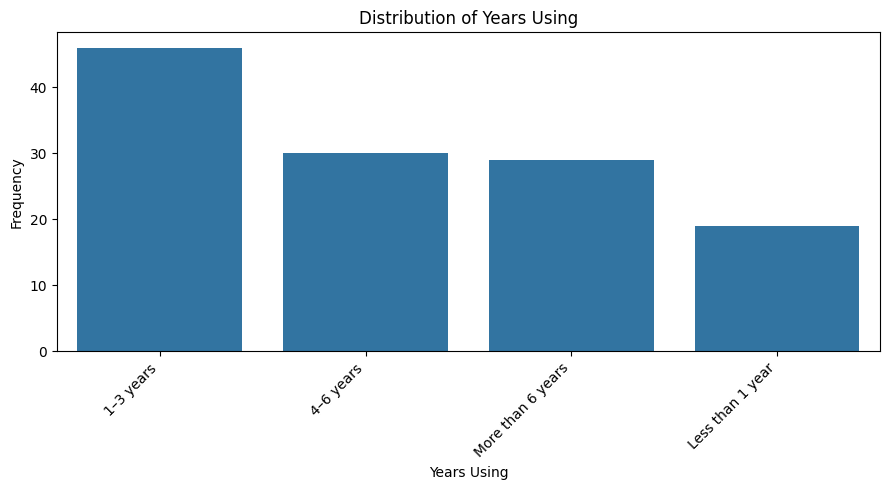

In [28]:
# ============================================================
# 9. DEMOGRAPHIC DISTRIBUTION CHARTS
# ============================================================

for variable in demographic_vars:

    plt.figure(figsize=(9, 5))

    order = (
        df[variable]
        .value_counts()
        .index
    )

    sns.countplot(
        data=df,
        x=variable,
        order=order
    )

    plt.title(
        f"Distribution of {variable.replace('_', ' ').title()}"
    )

    plt.xlabel(
        variable.replace("_", " ").title()
    )

    plt.ylabel("Frequency")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

Cybersecurity Awareness — Objective Scoring



In [29]:
# ============================================================
# 10. CORRECT ANSWERS — CYBERSECURITY AWARENESS
# ============================================================

correct_answers = {

    "C1":
    "T7#mQ9!vL2@p",

    "C2":
    "Avoid the link and contact the bank through its official channel",

    "C3":
    "An urgent request for personal or financial information",

    "C4":
    "To provide an additional layer of identity verification",

    "C5":
    "https://example.com",

    "C6":
    "Install the security update when appropriate",

    "C7":
    "Do not provide the information and verify through an official channel",

    "C8":
    "Avoid sensitive transactions on the unsecured network",

    "C9":
    "Change the password and follow the provider's security procedures",

    "C10":
    "They can help fix security vulnerabilities"
}

In [30]:
# ============================================================
# 11. INSPECT AWARENESS RESPONSES
# ============================================================

for item in awareness_items:

    print("\n" + "=" * 70)
    print(item)
    print("=" * 70)

    display(
        df[item]
        .value_counts(dropna=False)
        .to_frame("Frequency")
    )


C1


,Frequency
C1,
T7#mQ9!vL2@p,90
Name@123,16
12345678,12
password123,6



C2


,Frequency
C2,
Avoid the link and contact the bank through its official channel,106
Click the link and verify the account,13
Reply to the email for confirmation,3
Forward the email to friends,2



C3


...

,Frequency
C8,
Avoid sensitive transactions on the unsecured network,92
Disable device security features,15
Conduct sensitive financial transactions normally,14
Share passwords over the network,3



C9


,Frequency
C9,
Change the password and follow the provider's security procedures,89
Ignore the incident,24
Continue using the account normally,10
Share the password with friends,1



C10


,Frequency
C10,
They can help fix security vulnerabilities,84
They always reduce device security,21
They are generally unnecessary,12
They should always be disabled,7


In [31]:
# ============================================================
# 12. SCORE CYBERSECURITY AWARENESS
# ============================================================

def score_awareness(series, correct_answer):

    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .eq(
            correct_answer
            .strip()
            .lower()
        )
        .astype(int)
    )


for item in awareness_items:

    df[item + "_score"] = score_awareness(
        df[item],
        correct_answers[item]
    )

In [32]:
# ============================================================
# CHECK AWARENESS SCORING
# ============================================================

awareness_score_columns = [
    item + "_score"
    for item in awareness_items
]

display(
    df[awareness_score_columns]
    .head(10)
)

,C1_score,C2_score,C3_score,C4_score,C5_score,C6_score,C7_score,C8_score,C9_score,C10_score
0,1,1,1,1,1,0,1,1,1,1
1,1,1,1,0,1,1,1,1,1,1
2,1,1,1,1,0,1,1,1,1,1
3,1,1,1,1,0,1,1,1,1,1
4,1,1,0,0,0,0,1,1,0,1
5,1,1,0,1,0,0,1,1,1,1
6,1,0,1,1,0,1,0,0,0,1
7,1,1,1,0,0,0,1,0,1,0
8,1,1,1,0,0,1,1,0,0,0
9,1,1,1,1,1,0,0,0,0,0


In [33]:
# ============================================================
# 13. TOTAL CYBERSECURITY AWARENESS SCORE
# ============================================================

df["cybersecurity_awareness"] = (
    df[awareness_score_columns]
    .sum(axis=1)
)

print(
    df["cybersecurity_awareness"]
    .describe()
)

count   124.0000
mean      6.5000
std       2.7215
min       0.0000
25%       5.0000
50%       7.0000
75%       9.0000
max      10.0000
Name: cybersecurity_awareness, dtype: float64


In [34]:
# ============================================================
# 14. AWARENESS SCORE DISTRIBUTION
# ============================================================

awareness_distribution = (
    df["cybersecurity_awareness"]
    .value_counts()
    .sort_index()
    .to_frame("Frequency")
)

awareness_distribution["Percentage"] = (
    awareness_distribution["Frequency"]
    / len(df) * 100
)

display(
    awareness_distribution.round(2)
)

,Frequency,Percentage
cybersecurity_awareness,,
0,4,3.2300
1,3,2.4200
2,8,6.4500
3,2,1.6100
4,12,9.6800
5,15,12.1000
6,8,6.4500
7,15,12.1000
8,21,16.9400


In [35]:
# ============================================================
# 15. LIKERT SCALE CODING
# ============================================================

likert_mapping = {

    "strongly disagree": 1,
    "sd": 1,

    "disagree": 2,
    "d": 2,

    "neutral": 3,
    "n": 3,

    "agree": 4,
    "a": 4,

    "strongly agree": 5,
    "sa": 5
}

likert_items = (
    privacy_items +
    reliability_items +
    trust_items
)

for item in likert_items:

    # Try numerical values first
    numerical = pd.to_numeric(
        df[item],
        errors="coerce"
    )

    # Then try text values
    textual = (
        df[item]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(likert_mapping)
    )

    df[item + "_num"] = (
        numerical
        .fillna(textual)
    )

In [36]:
# ============================================================
# 15. LIKERT SCALE CODING
# ============================================================

likert_mapping = {

    "strongly disagree": 1,
    "sd": 1,

    "disagree": 2,
    "d": 2,

    "neutral": 3,
    "n": 3,

    "agree": 4,
    "a": 4,

    "strongly agree": 5,
    "sa": 5
}

likert_items = (
    privacy_items +
    reliability_items +
    trust_items
)

for item in likert_items:

    # Try numerical values first
    numerical = pd.to_numeric(
        df[item],
        errors="coerce"
    )

    # Then try text values
    textual = (
        df[item]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(likert_mapping)
    )

    df[item + "_num"] = (
        numerical
        .fillna(textual)
    )

In [37]:
# ============================================================
# 16. CHECK LIKERT CODING
# ============================================================

for item in likert_items:

    print(
        item,
        ":",
        sorted(
            df[item + "_num"]
            .dropna()
            .unique()
        )
    )

D1 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D2 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D3 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D4 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D5 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D6 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
D7 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
E1 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
E2 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
E3 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
E4 : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

In [38]:
# ============================================================
# 17. REVERSE CODING
# ============================================================

df["F4_num"] = 6 - df["F4_num"]

df["F6_num"] = 6 - df["F6_num"]

print("F4 and F6 reverse coded successfully.")

F4 and F6 reverse coded successfully.


In [39]:
# ============================================================
# 18. CREATE CONSTRUCT SCORES
# ============================================================

privacy_num = [
    x + "_num"
    for x in privacy_items
]

reliability_num = [
    x + "_num"
    for x in reliability_items
]

trust_num = [
    x + "_num"
    for x in trust_items
]


df["perceived_data_privacy"] = (
    df[privacy_num]
    .mean(axis=1)
)

df["system_reliability"] = (
    df[reliability_num]
    .mean(axis=1)
)

df["consumer_trust"] = (
    df[trust_num]
    .mean(axis=1)
)

In [40]:
# ============================================================
# 19. OBJECTIVE 1 — DESCRIPTIVE STATISTICS
# ============================================================

main_variables = [
    "cybersecurity_awareness",
    "perceived_data_privacy",
    "system_reliability",
    "consumer_trust"
]

descriptive_statistics = pd.DataFrame({

    "N": df[main_variables].count(),

    "Mean": df[main_variables].mean(),

    "SD": df[main_variables].std(),

    "Minimum": df[main_variables].min(),

    "Maximum": df[main_variables].max(),

    "Skewness": df[main_variables].skew(),

    "Kurtosis": df[main_variables].kurtosis()
})

display(
    descriptive_statistics.round(4)
)

,N,Mean,SD,Minimum,Maximum,Skewness,Kurtosis
cybersecurity_awareness,124,6.5000,2.7215,0.0000,10.0000,-0.6813,-0.4341
perceived_data_privacy,124,3.3560,0.6875,1.0000,4.8571,-0.3483,0.6080
system_reliability,124,3.6256,0.6475,2.1429,5.0000,0.2794,-0.0376
consumer_trust,124,3.3815,0.4602,1.8000,4.7000,-0.1288,0.8127


In [41]:
# ============================================================
# 20. CRONBACH'S ALPHA
# ============================================================

alpha_privacy = pg.cronbach_alpha(
    data=df[privacy_num].dropna()
)

alpha_reliability = pg.cronbach_alpha(
    data=df[reliability_num].dropna()
)

alpha_trust = pg.cronbach_alpha(
    data=df[trust_num].dropna()
)

reliability_table = pd.DataFrame({

    "Construct": [
        "Perceived Data Privacy",
        "System Reliability",
        "Consumer Trust"
    ],

    "Number of Items": [
        7,
        7,
        10
    ],

    "Cronbach's Alpha": [
        alpha_privacy[0],
        alpha_reliability[0],
        alpha_trust[0]
    ]
})

display(
    reliability_table.round(4)
)

,Construct,Number of Items,Cronbach's Alpha
0,Perceived Data Privacy,7,0.7284
1,System Reliability,7,0.8112
2,Consumer Trust,10,0.6050


Objective 1 Construct-Level Interpretation Table

In [42]:
# ============================================================
# 21. CONSTRUCT SUMMARY
# ============================================================

construct_summary = pd.DataFrame({

    "Construct": [
        "Cybersecurity Awareness",
        "Perceived Data Privacy",
        "System Reliability",
        "Consumer Trust"
    ],

    "Measurement": [
        "Objective score (0–10)",
        "Mean of D1–D7 (1–5)",
        "Mean of E1–E7 (1–5)",
        "Mean of F1–F10 (1–5)"
    ],

    "Mean": [
        df["cybersecurity_awareness"].mean(),
        df["perceived_data_privacy"].mean(),
        df["system_reliability"].mean(),
        df["consumer_trust"].mean()
    ],

    "SD": [
        df["cybersecurity_awareness"].std(),
        df["perceived_data_privacy"].std(),
        df["system_reliability"].std(),
        df["consumer_trust"].std()
    ],

    "Minimum": [
        df["cybersecurity_awareness"].min(),
        df["perceived_data_privacy"].min(),
        df["system_reliability"].min(),
        df["consumer_trust"].min()
    ],

    "Maximum": [
        df["cybersecurity_awareness"].max(),
        df["perceived_data_privacy"].max(),
        df["system_reliability"].max(),
        df["consumer_trust"].max()
    ]
})

display(
    construct_summary.round(4)
)

,Construct,Measurement,Mean,SD,Minimum,Maximum
0,Cybersecurity Awareness,Objective score (0–10),6.5000,2.7215,0.0000,10.0000
1,Perceived Data Privacy,Mean of D1–D7 (1–5),3.3560,0.6875,1.0000,4.8571
2,System Reliability,Mean of E1–E7 (1–5),3.6256,0.6475,2.1429,5.0000
3,Consumer Trust,Mean of F1–F10 (1–5),3.3815,0.4602,1.8000,4.7000


OBJECTIVE 2
Consumer Trust Across Demographic Groups
21. Independent-Samples t-Test

Use this when the demographic variable has exactly two groups

In [44]:
# ============================================================
# 22. INDEPENDENT-SAMPLES T-TEST
# ============================================================

def run_ttest(data, grouping_variable):

    temp = data[
        [
            grouping_variable,
            "consumer_trust"
        ]
    ].dropna()

    groups = temp[
        grouping_variable
    ].unique()

    print("\n" + "=" * 70)
    print(
        f"T-TEST: {grouping_variable}"
    )
    print("=" * 70)

    if len(groups) != 2:

        print(
            "This variable does not have exactly "
            "two groups."
        )

        print(
            "Number of groups:",
            len(groups)
        )

        return None

    group1 = temp.loc[
        temp[grouping_variable] == groups[0],
        "consumer_trust"
    ]

    group2 = temp.loc[
        temp[grouping_variable] == groups[1],
        "consumer_trust"
    ]

    # Welch t-test
    t_stat, p_value = ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    # Levene test
    lev_stat, lev_p = levene(
        group1,
        group2
    )

    result = pd.DataFrame({

        "Group 1": [groups[0]],

        "Group 2": [groups[1]],

        "N Group 1": [len(group1)],

        "N Group 2": [len(group2)],

        "Mean Group 1": [group1.mean()],

        "Mean Group 2": [group2.mean()],

        "t-statistic": [t_stat],

        "p-value": [p_value],

        "Levene p-value": [lev_p]
    })

    display(
        result.round(4)
    )

    return result

In [45]:
gender_ttest = run_ttest(
    df,
    "gender"
)


T-TEST: gender
This variable does not have exactly two groups.
Number of groups: 3


In [46]:
# ============================================================
# 23. ONE-WAY ANOVA
# ============================================================

def run_anova(data, grouping_variable):

    temp = data[
        [
            grouping_variable,
            "consumer_trust"
        ]
    ].dropna()

    groups = []

    names = []

    for name, group in temp.groupby(
        grouping_variable
    ):

        values = group[
            "consumer_trust"
        ].values

        if len(values) >= 2:

            groups.append(values)
            names.append(name)

    print("\n" + "=" * 70)
    print(
        f"ANOVA: {grouping_variable}"
    )
    print("=" * 70)

    for name, values in zip(
        names,
        groups
    ):

        print(
            f"{name}: "
            f"N={len(values)}, "
            f"Mean={np.mean(values):.4f}, "
            f"SD={np.std(values, ddof=1):.4f}"
        )

    if len(groups) < 2:

        print(
            "Not enough groups for ANOVA."
        )

        return None

    f_stat, p_value = f_oneway(
        *groups
    )

    # Eta squared
    grand_mean = temp[
        "consumer_trust"
    ].mean()

    ss_between = sum(
        len(values)
        * (np.mean(values) - grand_mean) ** 2
        for values in groups
    )

    ss_total = sum(
        (
            temp["consumer_trust"]
            - grand_mean
        ) ** 2
    )

    eta_squared = (
        ss_between / ss_total
    )

    result = pd.DataFrame({

        "Demographic": [
            grouping_variable
        ],

        "F-statistic": [
            f_stat
        ],

        "p-value": [
            p_value
        ],

        "Eta-squared": [
            eta_squared
        ]
    })

    display(
        result.round(4)
    )

    return result

In [47]:
# ============================================================
# 24. ANOVA — ALL DEMOGRAPHIC VARIABLES
# ============================================================

anova_variables = [
    "age",
    "education",
    "occupation",
    "income",
    "residence",
    "usage_frequency",
    "years_using"
]

anova_results = []

for variable in anova_variables:

    result = run_anova(
        df,
        variable
    )

    if result is not None:

        anova_results.append(
            result
        )

anova_summary = pd.concat(
    anova_results,
    ignore_index=True
)

display(
    anova_summary.round(4)
)


ANOVA: age
21–30: N=98, Mean=3.3694, SD=0.4582
31-40: N=7, Mean=3.6143, SD=0.3388
Below 20: N=18, Mean=3.3611, SD=0.5192


,Demographic,F-statistic,p-value,Eta-squared
0,age,0.9387,0.3940,0.0154



ANOVA: education
Diploma: N=7, Mean=3.4000, SD=0.5477
Higher Secondary: N=18, Mean=3.3667, SD=0.4839
Others: N=6, Mean=3.5167, SD=0.6242
Postgraduate: N=43, Mean=3.4000, SD=0.4282
Undergraduate: N=49, Mean=3.3592, SD=0.4636


,Demographic,F-statistic,p-value,Eta-squared
0,education,0.1764,0.9502,0.0060



ANOVA: occupation
Business: N=10, Mean=3.1500, SD=0.5017
Government Employee: N=2, Mean=3.8000, SD=0.4243
Homemaker: N=3, Mean=3.7333, SD=0.2517
Others: N=9, Mean=3.4556, SD=0.6106
Private Employee: N=18, Mean=3.2667, SD=0.3361
Self-employed: N=10, Mean=3.5200, SD=0.3645
Student: N=72, Mean=3.3875, SD=0.4693


...


ANOVA: usage_frequency
Daily: N=80, Mean=3.3650, SD=0.4723
Monthly: N=8, Mean=3.2375, SD=0.7269
Occasionally: N=12, Mean=3.4000, SD=0.3814
Weekly: N=24, Mean=3.4750, SD=0.3442


,Demographic,F-statistic,p-value,Eta-squared
0,usage_frequency,0.6264,0.5993,0.0154



ANOVA: years_using
1–3 years: N=46, Mean=3.2935, SD=0.4749
4–6 years: N=30, Mean=3.4000, SD=0.4127
Less than 1 year: N=19, Mean=3.5526, SD=0.5834
More than 6 years: N=29, Mean=3.3897, SD=0.3735


,Demographic,F-statistic,p-value,Eta-squared
0,years_using,1.4728,0.2254,0.0355


,Demographic,F-statistic,p-value,Eta-squared
0,age,0.9387,0.3940,0.0154
1,education,0.1764,0.9502,0.0060
2,occupation,1.3948,0.2225,0.0668
3,income,0.5354,0.7099,0.0177
4,residence,1.6688,0.1928,0.0268
5,usage_frequency,0.6264,0.5993,0.0154
6,years_using,1.4728,0.2254,0.0355


In [48]:
# ============================================================
# 25. TUKEY HSD POST-HOC
# ============================================================

def run_tukey(
    data,
    grouping_variable
):

    temp = data[
        [
            grouping_variable,
            "consumer_trust"
        ]
    ].dropna()

    print("\n" + "=" * 70)
    print(
        f"TUKEY HSD: {grouping_variable}"
    )
    print("=" * 70)

    tukey = pg.pairwise_tukey(
        data=temp,
        dv="consumer_trust",
        between=grouping_variable
    )

    display(
        tukey.round(4)
    )

    return tukey

In [49]:
# Example only:
# Run this if the ANOVA for AGE is significant.

tukey_age = run_tukey(
    df,
    "age"
)


TUKEY HSD: age


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,21–30,31-40,3.3694,3.6143,-0.2449,0.1808,-1.3542,0.5305,-0.5377
1,21–30,41-50,3.3694,3.3000,0.0694,0.4646,0.1494,0.9988,[0.15142332223533733]
2,21–30,Below 20,3.3694,3.3611,0.0083,0.1185,0.0698,0.9999,0.0176
3,31-40,41-50,3.6143,3.3000,0.3143,0.4942,0.6360,0.9202,[0.9277388999651758]
4,31-40,Below 20,3.6143,3.3611,0.2532,0.2059,1.2296,0.6093,0.5114
5,41-50,Below 20,3.3000,3.3611,-0.0611,0.4749,-0.1287,0.9992,NaN


In [50]:
# ============================================================
# 26. OBJECTIVE 3 — PEARSON CORRELATION
# ============================================================

correlation_variables = [
    "cybersecurity_awareness",
    "perceived_data_privacy",
    "system_reliability",
    "consumer_trust"
]

correlation_matrix = df[
    correlation_variables
].corr()

display(
    correlation_matrix.round(4)
)

,cybersecurity_awareness,perceived_data_privacy,system_reliability,consumer_trust
cybersecurity_awareness,1.0000,0.1338,0.3114,0.1178
perceived_data_privacy,0.1338,1.0000,0.4867,0.4737
system_reliability,0.3114,0.4867,1.0000,0.6407
consumer_trust,0.1178,0.4737,0.6407,1.0000


In [51]:
# ============================================================
# 27. CORRELATION WITH P-VALUES
# ============================================================

correlation_results = []

for variable in [
    "cybersecurity_awareness",
    "perceived_data_privacy",
    "system_reliability"
]:

    temp = df[
        [
            variable,
            "consumer_trust"
        ]
    ].dropna()

    r, p = pearsonr(
        temp[variable],
        temp["consumer_trust"]
    )

    correlation_results.append({

        "Variable": variable,

        "Pearson r": r,

        "p-value": p,

        "N": len(temp)
    })

correlation_results = pd.DataFrame(
    correlation_results
)

display(
    correlation_results.round(4)
)

,Variable,Pearson r,p-value,N
0,cybersecurity_awareness,0.1178,0.1925,124
1,perceived_data_privacy,0.4737,0.0000,124
2,system_reliability,0.6407,0.0000,124


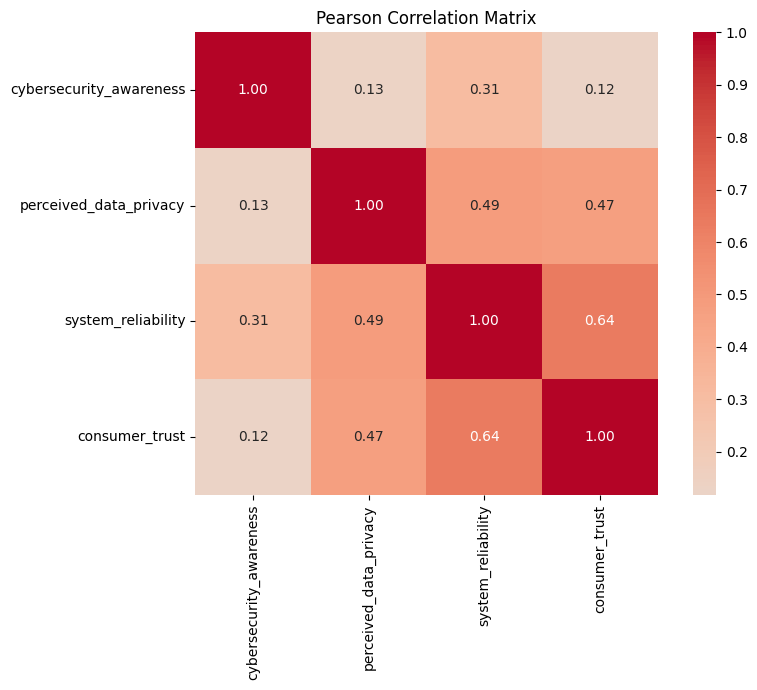

In [52]:
# ============================================================
# 28. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Pearson Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [53]:
# ============================================================
# 29. OBJECTIVE 4 — REGRESSION DATA
# ============================================================

regression_variables = [
    "consumer_trust",
    "cybersecurity_awareness",
    "perceived_data_privacy",
    "system_reliability"
]

reg_df = df[
    regression_variables
].dropna().copy()

print(
    "Regression sample size:",
    len(reg_df)
)

display(
    reg_df.describe().T
)

Regression sample size: 124


,count,mean,std,min,25%,50%,75%,max
consumer_trust,124.0000,3.3815,0.4602,1.8000,3.1000,3.4000,3.6000,4.7000
cybersecurity_awareness,124.0000,6.5000,2.7215,0.0000,5.0000,7.0000,9.0000,10.0000
perceived_data_privacy,124.0000,3.3560,0.6875,1.0000,3.0000,3.3571,3.7143,4.8571
system_reliability,124.0000,3.6256,0.6475,2.1429,3.1429,3.7143,4.0000,5.0000


In [54]:
# ============================================================
# 30. MULTIPLE LINEAR REGRESSION
# ============================================================

X = reg_df[
    [
        "cybersecurity_awareness",
        "perceived_data_privacy",
        "system_reliability"
    ]
]

y = reg_df[
    "consumer_trust"
]

X = sm.add_constant(X)

model = sm.OLS(
    y,
    X
).fit()

print(
    model.summary()
)

                            OLS Regression Results                            
Dep. Variable:         consumer_trust   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     32.93
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           1.34e-15
Time:                        18:44:51   Log-Likelihood:                -41.970
No. Observations:                 124   AIC:                             91.94
Df Residuals:                     120   BIC:                             103.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [56]:
# ============================================================
# 31. REGRESSION RESULTS TABLE
# ============================================================

regression_table = pd.DataFrame({

    "Coefficient": model.params,

    "Std. Error": model.bse,

    "t-statistic": model.tvalues,

    "p-value": model.pvalues,

    "CI Lower": model.conf_int()[0],

    "CI Upper": model.conf_int()[1]
})

display(
    regression_table.round(4)
)

,Coefficient,Std. Error,t-statistic,p-value,CI Lower,CI Upper
const,1.5479,0.1942,7.9700,0.0000,1.1634,1.9324
cybersecurity_awareness,-0.0146,0.0120,-1.2129,0.2276,-0.0384,0.0092
perceived_data_privacy,0.1406,0.0518,2.7141,0.0076,0.0380,0.2432
system_reliability,0.4017,0.0574,7.0024,0.0000,0.2881,0.5153


In [58]:
# ============================================================
# 32. MODEL FIT
# ============================================================

model_fit = pd.DataFrame({

    "R-squared": [
        model.rsquared
    ],

    "Adjusted R-squared": [
        model.rsquared_adj
    ],

    "F-statistic": [
        model.fvalue
    ],

    "F p-value": [
        model.f_pvalue
    ],

    "N": [
        int(model.nobs)
    ]
})

display(
    model_fit.round(4)
)

,R-squared,Adjusted R-squared,F-statistic,F p-value,N
0,0.4515,0.4378,32.9264,0.0000,124


In [60]:
from sklearn.preprocessing import StandardScaler

# ============================================================
# 33. STANDARDISED BETA
# ============================================================

predictors = [
    "cybersecurity_awareness",
    "perceived_data_privacy",
    "system_reliability"
]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_std = scaler_X.fit_transform(
    reg_df[predictors]
)

y_std = scaler_y.fit_transform(
    reg_df[["consumer_trust"]]
).flatten()

X_std = sm.add_constant(
    X_std
)

standardized_model = sm.OLS(
    y_std,
    X_std
).fit()

standardized_results = pd.DataFrame({

    "Variable": [
        "Constant",
        "Cybersecurity Awareness",
        "Perceived Data Privacy",
        "System Reliability"
    ],

    "Standardized Beta":
        standardized_model.params,

    "p-value":
        standardized_model.pvalues
})

display(
    standardized_results.round(4)
)

,Variable,Standardized Beta,p-value
0,Constant,-0.0000,1.0000
1,Cybersecurity Awareness,-0.0863,0.2276
2,Perceived Data Privacy,0.2101,0.0076
3,System Reliability,0.5653,0.0000


In [61]:
# ============================================================
# 34. VIF
# ============================================================

X_vif = reg_df[
    predictors
].copy()

X_vif = sm.add_constant(
    X_vif
)

vif_results = pd.DataFrame({

    "Variable": X_vif.columns,

    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            i
        )
        for i in range(
            X_vif.shape[1]
        )
    ]
})

display(
    vif_results.round(4)
)

,Variable,VIF
0,const,39.2854
1,cybersecurity_awareness,1.1079
2,perceived_data_privacy,1.3110
3,system_reliability,1.4258


In [62]:
# ============================================================
# 35. BREUSCH-PAGAN TEST
# ============================================================

bp = het_breuschpagan(
    model.resid,
    model.model.exog
)

bp_results = pd.DataFrame({

    "Test": [
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ],

    "Value": [
        bp[0],
        bp[1],
        bp[2],
        bp[3]
    ]
})

display(
    bp_results.round(4)
)

,Test,Value
0,LM Statistic,4.1758
1,LM p-value,0.2431
2,F Statistic,1.3940
3,F p-value,0.2480


In [63]:
# ============================================================
# 36. HC3 ROBUST REGRESSION
# ============================================================

robust_model = model.get_robustcov_results(
    cov_type="HC3"
)

print(
    robust_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:         consumer_trust   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     33.12
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           1.14e-15
Time:                        18:49:22   Log-Likelihood:                -41.970
No. Observations:                 124   AIC:                             91.94
Df Residuals:                     120   BIC:                             103.2
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [64]:
# ============================================================
# 37. ROBUST REGRESSION TABLE
# ============================================================

robust_table = pd.DataFrame({

    "Coefficient": robust_model.params,

    "Robust SE": robust_model.bse,

    "t-statistic": robust_model.tvalues,

    "p-value": robust_model.pvalues
})

robust_table.index = [
    "Constant",
    "Cybersecurity Awareness",
    "Perceived Data Privacy",
    "System Reliability"
]

display(
    robust_table.round(4)
)

,Coefficient,Robust SE,t-statistic,p-value
Constant,1.5479,0.1960,7.8978,0.0000
Cybersecurity Awareness,-0.0146,0.0121,-1.2068,0.2299
Perceived Data Privacy,0.1406,0.0533,2.6390,0.0094
System Reliability,0.4017,0.0618,6.5005,0.0000


In [65]:
# ============================================================
# 38. H2-H4 HYPOTHESIS TESTING
# ============================================================

hypothesis_results = pd.DataFrame({

    "Hypothesis": [
        "H2",
        "H3",
        "H4"
    ],

    "Independent Variable": [
        "Cybersecurity Awareness",
        "Perceived Data Privacy",
        "System Reliability"
    ],

    "Coefficient": [
        robust_model.params[1],
        robust_model.params[2],
        robust_model.params[3]
    ],

    "p-value": [
        robust_model.pvalues[1],
        robust_model.pvalues[2],
        robust_model.pvalues[3]
    ]
})

hypothesis_results["Decision"] = np.where(
    hypothesis_results["p-value"] < 0.05,
    "Supported",
    "Not Supported"
)

display(
    hypothesis_results.round(4)
)

,Hypothesis,Independent Variable,Coefficient,p-value,Decision
0,H2,Cybersecurity Awareness,-0.0146,0.2299,Not Supported
1,H3,Perceived Data Privacy,0.1406,0.0094,Supported
2,H4,System Reliability,0.4017,0.0000,Supported


In [66]:
# ============================================================
# 39. H1 SUMMARY TABLE
# ============================================================

h1_results = []

# ------------------------------------------------------------
# Gender
# ------------------------------------------------------------

temp = df[
    ["gender", "consumer_trust"]
].dropna()

gender_groups = temp["gender"].unique()

if len(gender_groups) == 2:

    g1 = temp.loc[
        temp["gender"] == gender_groups[0],
        "consumer_trust"
    ]

    g2 = temp.loc[
        temp["gender"] == gender_groups[1],
        "consumer_trust"
    ]

    statistic, p = ttest_ind(
        g1,
        g2,
        equal_var=False
    )

    h1_results.append({

        "Demographic": "Gender",

        "Test": "Independent-samples t-test",

        "Statistic": statistic,

        "p-value": p
    })

else:

    groups = [
        group["consumer_trust"].values
        for _, group in temp.groupby("gender")
    ]

    statistic, p = f_oneway(*groups)

    h1_results.append({

        "Demographic": "Gender",

        "Test": "One-way ANOVA",

        "Statistic": statistic,

        "p-value": p
    })


# ------------------------------------------------------------
# Other demographics
# ------------------------------------------------------------

for variable in anova_variables:

    temp = df[
        [variable, "consumer_trust"]
    ].dropna()

    groups = [
        group["consumer_trust"].values
        for _, group in temp.groupby(variable)
    ]

    if len(groups) >= 2:

        statistic, p = f_oneway(
            *groups
        )

        h1_results.append({

            "Demographic": variable,

            "Test": "One-way ANOVA",

            "Statistic": statistic,

            "p-value": p
        })


h1_summary = pd.DataFrame(
    h1_results
)

h1_summary["Decision"] = np.where(
    h1_summary["p-value"] < 0.05,
    "Significant difference",
    "No significant difference"
)

display(
    h1_summary.round(4)
)

,Demographic,Test,Statistic,p-value,Decision
0,Gender,One-way ANOVA,0.5093,0.6022,No significant difference
1,age,One-way ANOVA,0.6362,0.5931,No significant difference
2,education,One-way ANOVA,0.2756,0.9257,No significant difference
3,occupation,One-way ANOVA,1.3948,0.2225,No significant difference
4,income,One-way ANOVA,0.5354,0.7099,No significant difference
5,residence,One-way ANOVA,1.6688,0.1928,No significant difference
6,usage_frequency,One-way ANOVA,0.6264,0.5993,No significant difference
7,years_using,One-way ANOVA,1.4728,0.2254,No significant difference


In [67]:
# ============================================================
# 40. EXPORT RESULTS
# ============================================================

output_file = (
    "/content/"
    "Cybersecurity_Consumer_Trust_Analysis.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    # Objective 1
    descriptive_statistics.to_excel(
        writer,
        sheet_name="Descriptive Statistics"
    )

    construct_summary.to_excel(
        writer,
        sheet_name="Construct Summary",
        index=False
    )

    reliability_table.to_excel(
        writer,
        sheet_name="Reliability",
        index=False
    )

    # Objective 2
    h1_summary.to_excel(
        writer,
        sheet_name="H1 Demographics",
        index=False
    )

    anova_summary.to_excel(
        writer,
        sheet_name="ANOVA",
        index=False
    )

    # Objective 3
    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation Matrix"
    )

    correlation_results.to_excel(
        writer,
        sheet_name="Correlation Results",
        index=False
    )

    # Objective 4
    regression_table.to_excel(
        writer,
        sheet_name="Regression"
    )

    robust_table.to_excel(
        writer,
        sheet_name="Robust Regression"
    )

    model_fit.to_excel(
        writer,
        sheet_name="Model Fit",
        index=False
    )

    vif_results.to_excel(
        writer,
        sheet_name="VIF",
        index=False
    )

    hypothesis_results.to_excel(
        writer,
        sheet_name="H2-H4 Hypotheses",
        index=False
    )

print(
    "Analysis results successfully exported."
)

print(
    "File:",
    output_file
)

Analysis results successfully exported.
File: /content/Cybersecurity_Consumer_Trust_Analysis.xlsx
